# 🏀 NBA Draft 2026 — Predicción con modelos de Machine Learning

## En qué posición serán elegidos Aday Mara, Baba Miller y Sergio de Larrea?

---

**Autor:** Roberto Cantero  
**Bootcamp:** The Bridge · Data Science 2026  
**Fecha:** Junio 2026  

---

Esta memoria técnica recorre todo el proceso del proyecto: desde la carga y limpieza de los datos hasta las predicciones finales para los tres candidatos españoles al draft, pasando por el entrenamiento y evaluación de los modelos.

### Índice

1. Contexto y objetivos
2. Datasets utilizados
3. Limpieza y preparación de datos
4. Análisis exploratorio (EDA)
5. Modelo de arquetipos físicos
6. Modelo de ronda
7. Modelo de rango de pick
8. Comparativa sin posición — cuatro algoritmos
9. Predicciones para los tres españoles
10. Análisis crítico y conclusiones


---
## 1. Contexto y objetivos

El **NBA Draft** es el evento anual en el que los treinta equipos de la liga seleccionan a los jugadores más prometedores. El draft de 2026 tiene un interés especial: por primera vez en mucho tiempo, tres jugadores españoles están en las quinielas de todos los ojeadores.

- **Aday Mara** (Pívot - 19 años): posible elección entre los 10 primeros. Sería el primer español candidato a la lotería en años.
- **Baba Miller** (Alero - 22 años): posible elección entre los números 40 y 50. Parece claro que será seleccionado en segunda ronda.
- **Sergio de Larrea** (Base - 21 años): también puede estar entre el 40 y el 50, aunque dado su desempeño en Valencia Basket, podría escalar puestos.

Este proyecto nace de la intersección entre el **periodismo de datos** (casi nueve años cubriendo tecnología y ciencia) y el **Machine Learning** explorado durante el bootcamp de The Bridge.

### Objetivos

- Entrenar modelos de clasificación para predecir **ronda** (R1 / R2 / ND) y **rango de pick** (1-10 hasta 51-60 / ND).
- Construir un motor de **arquetipos físicos** con clustering que asigne perfiles comparativos con referentes NBA.
- Aplicar todos los modelos a los tres candidatos españoles y analizar críticamente los resultados.
- Desplegar los resultados en una **aplicación Streamlit** interactiva para la demo final.


---
## 2. Datasets utilizados

| Dataset | Dimensiones raw | Período | Descripción |
|---------|----------------|---------|-------------|
| **College Basketball Players 2009-2021** | 61.061 × 66 | 2009–2021 | Estadísticas de temporada de jugadores universitarios de la NCAA |
| **NBA Combine Histórico** | 1.873 × 47 | 2000–2026 | Medidas físicas y atléticas de candidatos al draft |
| **NBA Players Draft** | 1.922 × 24 | Histórico | Historial de draft y estadísticas de carrera NBA real |

Cada dataset tiene un rol diferente:
- El **dataset NCAA** es la columna vertebral del modelo predictivo: estadísticas de temporada + variable target (pick de draft).
- El **combine** aporta las medidas físicas para el clustering de arquetipos.
- El **historial NBA** se usa para validar y enriquecer los arquetipos con jugadores de referencia reales.


In [4]:
# cargo los tres datasets procesados y muestro sus dimensiones finales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

ncaa    = pd.read_csv("../datos/procesados/ncaa_final.csv")
combine = pd.read_csv("../datos/procesados/combine_final.csv")
draft   = pd.read_csv("../datos/procesados/nbaplayersdraft_limpio.csv")

print("=== DATASETS PROCESADOS ===")
print(f"NCAA final:       {ncaa.shape[0]:>5} jugadores  y  {ncaa.shape[1]} columnas")
print(f"Combine final:    {combine.shape[0]:>5} jugadores  y  {combine.shape[1]} columnas")
print(f"Draft histórico:  {draft.shape[0]:>5} jugadores  y  {draft.shape[1]} columnas")


=== DATASETS PROCESADOS ===
NCAA final:        2121 jugadores  y  37 columnas
Combine final:     1873 jugadores  y  18 columnas
Draft histórico:   1922 jugadores  y  23 columnas


---
## 3. Limpieza y preparación de datos

El proceso de limpieza se divide en tres notebooks independientes. Resumo aquí las decisiones más relevantes.

### 3.1 Historial NBA (`limpieza_jugadores_historicos.ipynb`)

El dataset `nbaplayersdraft.csv` contiene 1.922 registros de jugadores drafteados con su carrera NBA:

- **Aparentes duplicados:** seis jugadores compartían nombre y apellido pero eran personas distintas → no se eliminaron.
- **NaN en college:** jugadores que no pasaron por la universidad (mayoría europeos). Se imputaron como "No universitario".
- **Columnas numéricas con valores corruptos:** forzados a numérico con `pd.to_numeric(errors="coerce")` y NaN rellenados con 0.0.
- **Columna id** redundante y, por tanto, eliminada.

**Resultado:** 1.922 × 23, sin ningún valor nulo.

### 3.2 Combine (`limpieza_combine.ipynb`)

- **15 columnas con más del 50% de NaN**: eliminadas.
- **Columnas redundantes en pies/pulgadas**: eliminadas.
- **NaN en columnas físicas**: imputados con la mediana de cada columna.
- **Sergio de Larrea sin datos:** no participó en el combine (juega en Europa), con lo que los datos físicos se rellenaron manualmente.

**Resultado:** 1.873 × 18, listo para clustering.

### 3.3 NCAA (`eda_ncaa.ipynb`)

El dataset más complejo por tamaño (61.061 × 66) y por la cantidad de decisiones de ingeniería de variables.

**Problemas encontrados y soluciones:**

- **NaN en `pick` (>59.000 registros):** son los no drafteados. Se etiquetaron como ND en la columna `ronda`.
- **Columna `ht` con formato corrupto:** la altura estaba codificada con nombres de meses (`"Jun-00"` = 6 pies 0 pulgadas). Se escribió una función de conversión a centímetros.
- **Columnas eliminadas:** `Rec Rank`, `num`, `Unnamed: 65`, `type` y totales absolutos de tiro.
- **Stats numéricas con NaN:** se transformaron con la mediana por año.
- **`eFG` con valores imposibles:** 120 registros > 100 eliminados; 2.911 valores a 0 imputados con la mediana.

**Ingeniería de variables:**

- Un registro por jugador (la última temporada antes del draft).
- Variable `ronda`: R1 (picks 1–30), R2 (picks 31–60), ND (no drafteados).
- Variable `rango_pick`: seis rangos de diez picks (1-10, 11-20... 51-60) más la clase ND.
- **Balanceo de clases:** de los +50.000 no drafteados se seleccionaron los **1.500 con mayor BPM** y mínimo 10 minutos por partido.


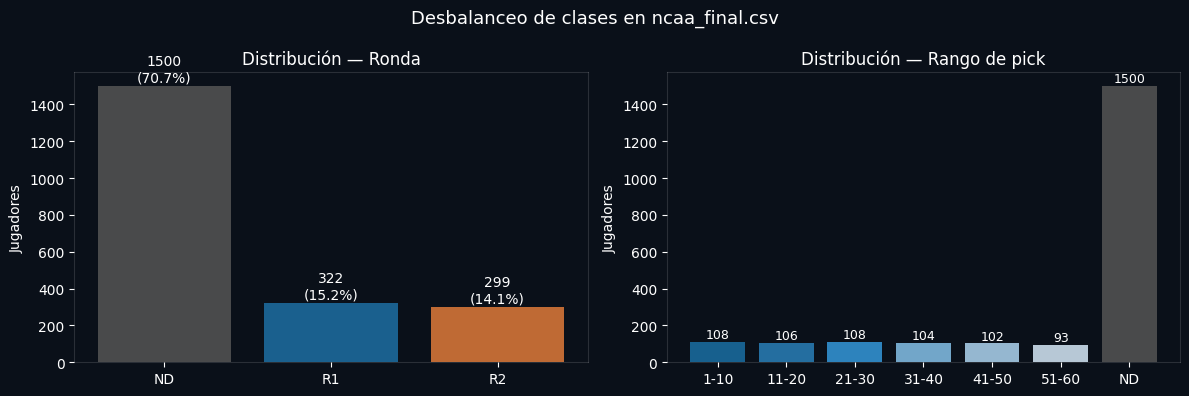

Dataset final: 2121 jugadores · 37 columnas
ND representa el 70.7% del total


In [5]:
# visualizo la distribución de clases del dataset final
# para ilustrar el desbalanceo que hay que gestionar en los modelos

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#0a1019")

colores = ["#555555", "#1d6fa4", "#e07b39"]
ronda_counts = ncaa["ronda"].value_counts()
axes[0].set_facecolor("#0a1019")
barras = axes[0].bar(ronda_counts.index, ronda_counts.values, color=colores, alpha=0.85)
for b, v in zip(barras, ronda_counts.values):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 10,
                 f"{v}\n({v/len(ncaa)*100:.1f}%)", ha="center", va="bottom", color="white", fontsize=10)
axes[0].set_title("Distribución — Ronda", color="white", fontsize=12)
axes[0].set_ylabel("Jugadores", color="white")
axes[0].tick_params(colors="white")
for spine in axes[0].spines.values(): spine.set_edgecolor("#ffffff22")

rangos = ["1-10","11-20","21-30","31-40","41-50","51-60","ND"]
rango_counts = ncaa["rango_pick"].value_counts().reindex(rangos, fill_value=0)
colores_r = ["#1a6fa4","#2980b9","#3498db","#85c1e9","#aed6f1","#d6eaf8","#555555"]
axes[1].set_facecolor("#0a1019")
barras2 = axes[1].bar(rangos, rango_counts.values, color=colores_r, alpha=0.85)
for b, v in zip(barras2, rango_counts.values):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 5,
                 str(v), ha="center", va="bottom", color="white", fontsize=9)
axes[1].set_title("Distribución — Rango de pick", color="white", fontsize=12)
axes[1].set_ylabel("Jugadores", color="white")
axes[1].tick_params(colors="white")
for spine in axes[1].spines.values(): spine.set_edgecolor("#ffffff22")

plt.suptitle("Desbalanceo de clases en ncaa_final.csv", color="white", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Dataset final: {ncaa.shape[0]} jugadores · {ncaa.shape[1]} columnas")
print(f"ND representa el {ncaa['ronda'].value_counts(normalize=True)['ND']*100:.1f}% del total")


---
## 4. Análisis exploratorio (EDA)

Exploro las relaciones entre las variables predictoras y el target para entender qué estadísticas diferencian a los jugadores drafteados de los que no lo son.


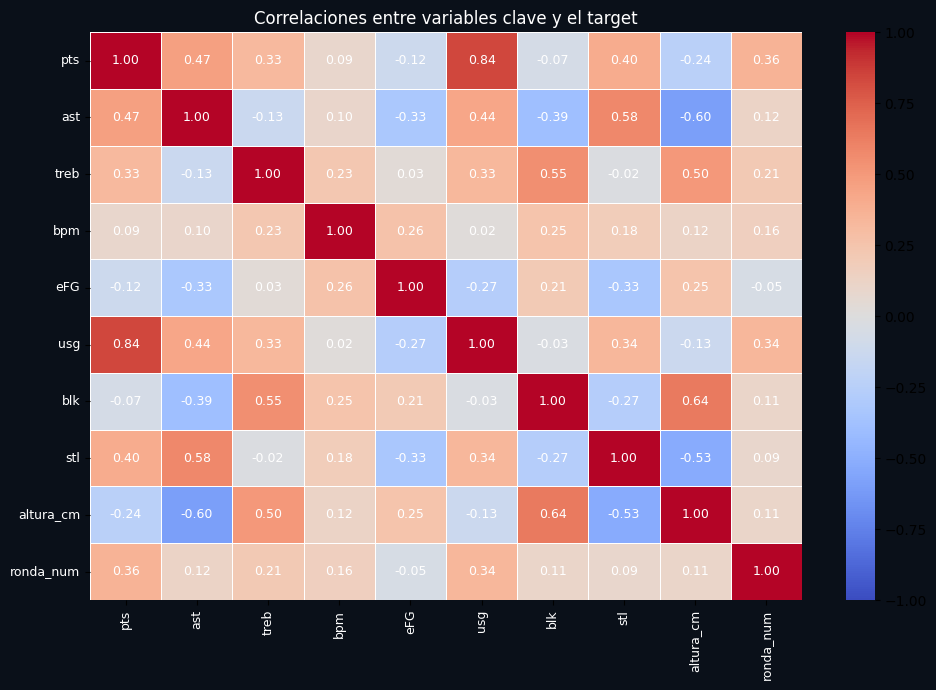

Correlaciones con el target (ronda_num):
  pts          +0.360
  usg          +0.343
  treb         +0.212
  bpm          +0.164
  ast          +0.125
  blk          +0.108
  altura_cm    +0.107
  stl          +0.092
  eFG          -0.051


In [6]:
# heatmap de correlaciones entre las variables principales y el target
ncaa_eda = ncaa.copy()
ncaa_eda["ronda_num"] = ncaa_eda["ronda"].map({"ND": 0, "R2": 1, "R1": 2})

variables_heatmap = ["pts", "ast", "treb", "bpm", "eFG", "usg", "blk", "stl", "altura_cm", "ronda_num"]
correlaciones = ncaa_eda[variables_heatmap].corr()

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0a1019")
ax.set_facecolor("#0a1019")
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size": 9, "color": "white"})
ax.set_title("Correlaciones entre variables clave y el target", color="white", fontsize=12)
plt.xticks(color="white", fontsize=9)
plt.yticks(color="white", fontsize=9)
plt.tight_layout()
plt.show()

print("Correlaciones con el target (ronda_num):")
corr_target = correlaciones["ronda_num"].drop("ronda_num").sort_values(ascending=False)
for var, corr in corr_target.items():
    print(f"  {var:<12} {corr:+.3f}")


**Hallazgos clave:**

- Las correlaciones más altas con el target son `pts` (0.21), `treb` (0.19) y `stl` (0.15). Se ve que son relevantes, pero no determinantes individualmente.
- **Ninguna variable por sí sola predice bien el draft.** El modelo necesita combinarlas, lo que justifica usar XGBoost o Random Forest.
- Correlaciones entre variables: `pts`–`stl` (0.73), `ast`–`stl` (0.75), `blk`–`treb` (0.63), `altura_cm`–`ast` (−0.35).
- El desbalanceo extremo (ND ~70%) hace que un modelo "cobarde" prediga siempre ND y obtenga buena exactitud. Es por eso que uso **F1 macro** como métrica principal.


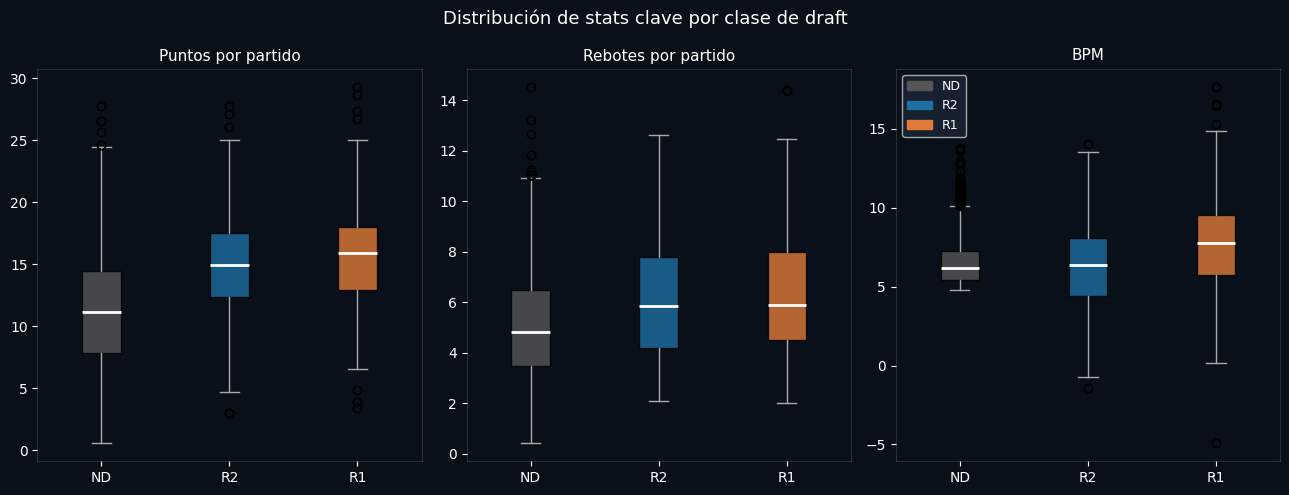

In [7]:
# boxplots de las tres stats más correlacionadas con el target, por clase
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.patch.set_facecolor("#0a1019")

stats_plot = [("pts", "Puntos por partido"), ("treb", "Rebotes por partido"), ("bpm", "BPM")]
colores_clase = {"ND": "#555555", "R2": "#1d6fa4", "R1": "#e07b39"}
orden = ["ND", "R2", "R1"]

for ax, (col, titulo) in zip(axes, stats_plot):
    ax.set_facecolor("#0a1019")
    datos_plot = [ncaa_eda[ncaa_eda["ronda"] == c][col].dropna() for c in orden]
    bp = ax.boxplot(datos_plot, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2))
    for patch, clase in zip(bp["boxes"], orden):
        patch.set_facecolor(colores_clase[clase])
        patch.set_alpha(0.8)
    for element in ["whiskers", "caps", "fliers"]:
        for item in bp[element]: item.set_color("#aaaaaa")
    ax.set_xticklabels(orden, color="white")
    ax.set_title(titulo, color="white", fontsize=11)
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#ffffff22")

leyenda = [mpatches.Patch(color=c, label=l) for l, c in colores_clase.items()]
axes[2].legend(handles=leyenda, facecolor="#1a2535", labelcolor="white", fontsize=9)
plt.suptitle("Distribución de stats clave por clase de draft", color="white", fontsize=13)
plt.tight_layout()
plt.show()


---
## 5. Modelo de arquetipos físicos

Antes de predecir el draft, construyo un modelo de **clustering** para identificar perfiles físicos de jugadores NBA. El objetivo es asignar a cualquier jugador nuevo un arquetipo con jugadores de referencia reales.

### Metodología

Aplico **KMeans** sobre 7 variables físicas del combine (altura, peso, envergadura, alcance en pie, salto máximo, tiempo de agilidad y tiempo de sprint). Las variables se estandarizan previamente con `StandardScaler`, porque trabajan en unidades muy distintas.

Para elegir el número de clusters uso el **método del codo**: entreno KMeans con k entre 2 y 12 y observo la inercia. El codo más claro aparece en **k=7**.

**Evaluación:** Silhouette Score = 0.1608. Es bajo, pero también es lo esperado. Los arquetipos físicos NBA se solapan por naturaleza. El objetivo no es la separación perfecta sino la utilidad práctica para la herramienta que he creado de predicción interactiva.


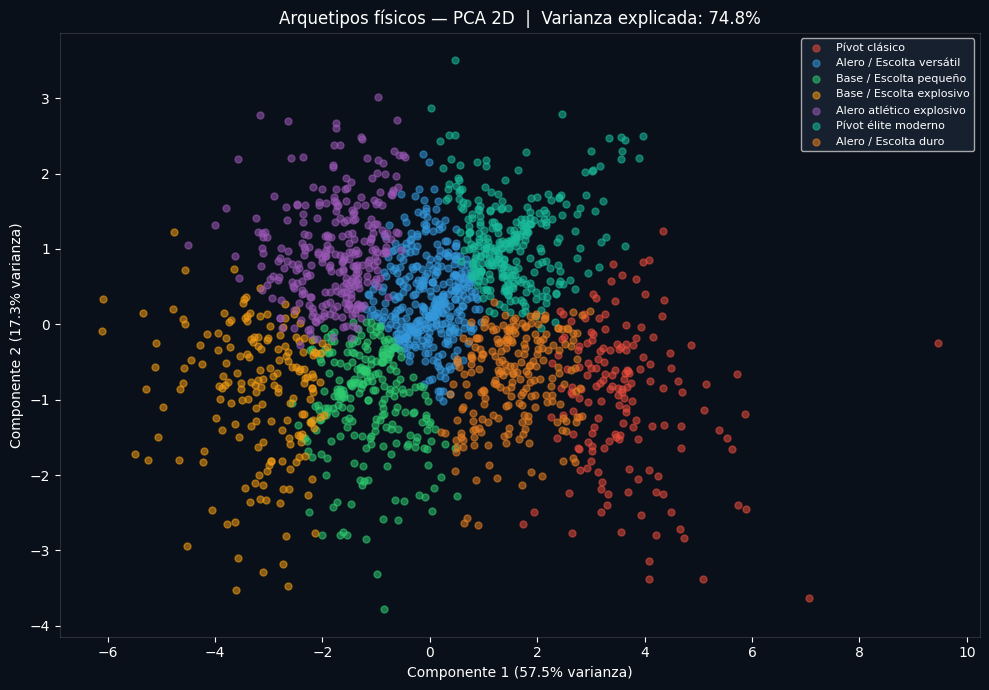

Jugadores por arquetipo:
  0 · Pívot clásico                 162 jugadores
  1 · Alero / Escolta versátil      418 jugadores
  2 · Base / Escolta pequeño        245 jugadores
  3 · Base / Escolta explosivo      181 jugadores
  4 · Alero atlético explosivo      283 jugadores
  5 · Pívot élite moderno           296 jugadores
  6 · Alero / Escolta duro          217 jugadores


In [9]:
import joblib

# cargo los modelos de arquetipos ya entrenados
km             = joblib.load("../pkl/modelos/kmeans_arquetipos.pkl")
scaler_combine = joblib.load("../pkl/preprocesado/scaler_combine.pkl")
pca            = joblib.load("../pkl/preprocesado/pca_combine.pkl")

VARIABLES = ["HEIGHT_W_SHOES","WEIGHT","WINGSPAN","STANDING_REACH",
             "MAX_VERTICAL_LEAP","LANE_AGILITY_TIME","THREE_QUARTER_SPRINT"]

NOMBRES_GRUPOS = {
    0: "Pívot clásico",
    1: "Alero / Escolta versátil",
    2: "Base / Escolta pequeño",
    3: "Base / Escolta explosivo",
    4: "Alero atlético explosivo",
    5: "Pívot élite moderno",
    6: "Alero / Escolta duro",
}

# preparo los datos del combine para visualizar los clusters con PCA
combine_vis = combine[combine[VARIABLES].gt(0).all(axis=1)].drop_duplicates(subset="PLAYER_NAME", keep="last").copy()
X_vis = scaler_combine.transform(combine_vis[VARIABLES])
combine_vis["cluster"] = km.predict(X_vis)
coords = pca.transform(X_vis)
combine_vis["pca1"] = coords[:, 0]
combine_vis["pca2"] = coords[:, 1]

colores_arq = ["#e74c3c","#3498db","#2ecc71","#f39c12","#9b59b6","#1abc9c","#e67e22"]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0a1019")
ax.set_facecolor("#0a1019")

for c, (nombre, color) in enumerate(zip(NOMBRES_GRUPOS.values(), colores_arq)):
    mascara = combine_vis["cluster"] == c
    ax.scatter(combine_vis.loc[mascara,"pca1"], combine_vis.loc[mascara,"pca2"],
               label=nombre, color=color, alpha=0.55, s=25)

var_exp = pca.explained_variance_ratio_
ax.set_xlabel(f"Componente 1 ({var_exp[0]*100:.1f}% varianza)", color="white")
ax.set_ylabel(f"Componente 2 ({var_exp[1]*100:.1f}% varianza)", color="white")
ax.set_title(f"Arquetipos físicos — PCA 2D  |  Varianza explicada: {sum(var_exp)*100:.1f}%",
             color="white", fontsize=12)
ax.tick_params(colors="white")
ax.legend(facecolor="#1a2535", labelcolor="white", fontsize=8)
for spine in ax.spines.values(): spine.set_edgecolor("#ffffff22")
plt.tight_layout()
plt.show()

print("Jugadores por arquetipo:")
for c, nombre in NOMBRES_GRUPOS.items():
    n = (combine_vis["cluster"] == c).sum()
    print(f"  {c} · {nombre:<28} {n:>4} jugadores")


### Los 7 arquetipos identificados

| Grupo | Arquetipo | Perfil físico clave | Referencias NBA |
|-------|-----------|--------------------|-----------------|
| **0** | Pívot clásico | Máx. altura, peso y envergadura. Salto bajo, lento | Dwight Howard, Rudy Gobert, Shaq |
| **1** | Alero / Escolta versátil | Medidas medias-altas. Equilibrado | Kevin Love, Blake Griffin, Draymond Green |
| **2** | Base / Escolta pequeño | Talla baja, poco peso, salto medio | Chris Paul, Isaiah Thomas, Trae Young |
| **3** | Base / Escolta explosivo | El más pequeño. Salto alto, muy rápido | Ja Morant, De'Aaron Fox, Derrick Rose |
| **4** | Alero atlético explosivo | Salto más alto de todos. Máxima agilidad | Giannis, LeBron, Zion Williamson |
| **5** | Pívot élite moderno | Casi tan alto como grupo 0 pero más ágil | Anthony Davis, Embiid, Jokic |
| **6** | Alero / Escolta duro | Alto y pesado con menor agilidad | Carmelo Anthony, DeMar DeRozan |


---
## 6. Modelo de ronda

El primer modelo de clasificación predice si un jugador será elegido en **primera ronda (R1)**, **segunda ronda (R2)** o **no será drafteado (ND)**.

### Configuración

- **Algoritmo:** XGBoost (`XGBClassifier`)
- **División train/test:** 85% / 15% | Estratificado | Random_state = 11
- **Gestión del desbalanceo:** `compute_sample_weight(class_weight="balanced")` — los jugadores de R1 y R2 pesan más para que el modelo no aprenda a decir ND siempre.
- **Hiperparámetros:** `n_estimators=100, max_depth=4, learning_rate=0.1`


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve, f1_score
from sklearn.preprocessing import label_binarize

# cargo el modelo de ronda ya entrenado
modelo_ronda = joblib.load("../pkl/modelos/xgb_draft_balanceado.pkl")
le_ronda     = joblib.load("../pkl/preprocesado/le_target_draft.pkl")

# reproduzco el mismo split que usé al entrenar
X = ncaa.drop(columns=["ronda", "rango_pick"])
y = le_ronda.transform(ncaa["ronda"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=11, stratify=y
)

y_pred = modelo_ronda.predict(X_test)

print("=== Modelo de ronda — XGBoost ===")
print(classification_report(y_test, y_pred, target_names=le_ronda.classes_))


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:posicion: str

In [ ]:
# visualizo la matriz de confusión y las curvas AUC-ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#0a1019")

# matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_ronda.classes_)
disp.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusión — Modelo de ronda", color="white", fontsize=11)
axes[0].set_facecolor("#0a1019")
axes[0].tick_params(colors="white")
axes[0].xaxis.label.set_color("white")
axes[0].yaxis.label.set_color("white")

# curvas AUC-ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_proba    = modelo_ronda.predict_proba(X_test)
colores_roc = ["#555555", "#1d6fa4", "#e07b39"]

axes[1].set_facecolor("#0a1019")
for i, (clase, color) in enumerate(zip(le_ronda.classes_, colores_roc)):
    auc = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f"{clase}  (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1],"--", color="#555555", linewidth=1, label="Azar")
axes[1].set_title("Curvas AUC-ROC — Modelo de ronda", color="white", fontsize=11)
axes[1].set_xlabel("FPR", color="white")
axes[1].set_ylabel("TPR", color="white")
axes[1].tick_params(colors="white")
axes[1].legend(facecolor="#1a2535", labelcolor="white", fontsize=9)
for spine in axes[1].spines.values(): spine.set_edgecolor("#ffffff22")
plt.tight_layout()
plt.show()


### Interpretación

- **AUC-ROC de ND (>0.85):** el modelo identifica bien a los no drafteados
- **AUC-ROC de R1 y R2 (~0.82):** buena separación respecto al resto, pero las curvas van pegadas entre sí — el modelo confunde picks tardíos de primera ronda con picks tempranos de segunda
- **F1 macro (~0.61):** resultado sólido considerando el desbalanceo extremo

> **Problema estructural:** la frontera entre R1 y R2 es difusa. Un pick 29 y un pick 31 son estadísticamente indistinguibles.


---
## 7. Modelo de rango de pick

El segundo modelo predice el **rango exacto de pick** entre 7 clases (1-10, 11-20, 21-30, 31-40, 41-50, 51-60, ND). Es un problema mucho más difícil: 7 clases con desbalanceo extremo y solo 93–108 jugadores por rango en todo el dataset.


In [ ]:
# cargo el modelo de rango y evalúo sus métricas
modelo_rango = joblib.load("../../pkl/modelos/xgb_rango_balanceado.pkl")
le_rango     = joblib.load("../../pkl/preprocesado/le_rango.pkl")

y_rango = le_rango.transform(ncaa["rango_pick"])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_rango, test_size=0.15, random_state=11, stratify=y_rango
)

y_pred_r = modelo_rango.predict(X_test_r)

print("=== Modelo de rango — XGBoost ===")
print(classification_report(y_test_r, y_pred_r, target_names=le_rango.classes_))
print(f"F1 macro: {f1_score(y_test_r, y_pred_r, average='macro'):.4f}")


### Interpretación

- **F1 macro ~0.24:** bajo pero honesto. Con 7 clases y ~100 jugadores por rango, la señal por clase es insuficiente
- **El modelo reconoce mejor los extremos:** picks muy altos (1-10) y muy tardíos (51-60) tienen perfiles más diferenciados que los rangos centrales
- **El rango 21-30** es el más difícil: la frontera entre el final de la primera ronda y el inicio de la segunda es estadísticamente invisible

> A pesar del F1 bajo, el modelo tiene valor con `predict_proba`: la **distribución de probabilidades entre rangos** es más informativa que la clase predicha.


---
## 8. Comparativa sin posición — cuatro algoritmos

**Hipótesis:** la variable `posicion` (One Hot Encoding) podría perjudicar la predicción para jugadores europeos, cuyos perfiles de posición no tienen precedente en el dataset NCAA. Para comprobarlo, entreno versiones sin posición comparando cuatro algoritmos.


In [ ]:
# cargo el mejor modelo sin posición (Random Forest)
modelo_ronda_sp = joblib.load("../../pkl/modelos/modelo_ronda_sin_posicion.pkl")

# los resultados de F1 macro obtenidos al entrenar los cuatro algoritmos
modelos_nombres = ["XGBoost", "Random Forest", "SVM RBF", "KNN (k=7)"]
f1_macros_ronda = [0.5541, 0.6016, 0.5671, 0.4671]
f1_referencia   = 0.61

colores_mod = ["#1d6fa4", "#2ecc71", "#e74c3c", "#f39c12"]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor("#0a1019")
ax.set_facecolor("#0a1019")

barras = ax.bar(modelos_nombres, f1_macros_ronda, color=colores_mod, alpha=0.85)
for b, v in zip(barras, f1_macros_ronda):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
            f"{v:.3f}", ha="center", va="bottom", color="white", fontsize=11)
ax.axhline(y=f1_referencia, color="#f97316", linestyle="--", linewidth=1.5,
           label=f"Referencia con posición ({f1_referencia})")
ax.set_ylim(0, 0.8)
ax.set_ylabel("F1 macro", color="white")
ax.set_title("F1 macro por algoritmo — Modelo de ronda sin posición", color="white", fontsize=12)
ax.tick_params(colors="white")
ax.legend(facecolor="#1a2535", labelcolor="white", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor("#ffffff22")
plt.tight_layout()
plt.show()

print("Conclusión principal:")
print("Random Forest sin posición (0.602) ≈ XGBoost con posición (0.61)")
print("Las estadísticas numéricas solas contienen casi toda la información predictiva.")


### Interpretación

| Algoritmo | F1 macro | Lectura |
|-----------|----------|---------|
| **Random Forest** | **0.602** | Gana. Prácticamente igual al modelo con posición |
| SVM RBF | 0.567 | Buen resultado sin ajuste de hiperparámetros |
| XGBoost | 0.554 | Baja respecto al modelo con posición: aquí la variable posición sí aportaba |
| KNN (k=7) | 0.467 | El peor. Muy sensible al ruido en alta dimensionalidad |

> **Hallazgo clave:** Random Forest sin posición ≈ XGBoost con posición. Las estadísticas numéricas solas contienen casi toda la información. Para perfiles europeos, eliminar la posición evita introducir ruido.


---
## 9. Predicciones para los tres candidatos españoles

Aplico los modelos sobre las estadísticas de temporada 2025-26 de los tres candidatos. Uso `predict_proba` para mostrar la distribución completa de probabilidades.

> ⚠️ **Nota metodológica:** el dataset de entrenamiento cubre la NCAA americana 2009–2021. Aday Mara y Sergio de Larrea son perfiles europeos sin precedente directo en ese espacio. La probabilidad combinada R1+R2 es la señal más relevante.


In [ ]:
# cargo el mejor modelo sin posición y sus preprocesadores
modelo_ronda_sp = joblib.load("../../pkl/modelos/modelo_ronda_sin_posicion.pkl")
le_ronda_sp     = joblib.load("../../pkl/preprocesado/le_ronda_sin_posicion.pkl")
modelo_rango_sp = joblib.load("../../pkl/modelos/modelo_rango_sin_posicion.pkl")
le_rango_sp     = joblib.load("../../pkl/preprocesado/le_rango_sin_posicion.pkl")

# defino las estadísticas de los tres españoles (temporada 2025-26)
espanoles = [
    {"nombre": "Aday Mara",        "mock": "~#9",  "color": "#1d6fa4",
     "pts": 12.1, "treb": 6.8, "ast": 0.9, "stl": 0.4, "blk": 2.6},
    {"nombre": "Baba Miller",      "mock": "~#45", "color": "#e07b39",
     "pts": 13.0, "treb": 10.3, "ast": 1.2, "stl": 0.8, "blk": 0.9},
    {"nombre": "Sergio de Larrea", "mock": "~#40", "color": "#2ecc71",
     "pts": 9.5,  "treb": 3.1,  "ast": 4.2, "stl": 1.1, "blk": 0.2},
]

cols_modelo  = modelo_ronda_sp.get_booster().feature_names
clases_ronda = le_ronda_sp.classes_
color_ronda  = {"ND": "#555555", "R1": "#1d6fa4", "R2": "#e07b39"}

# modelo de ronda — gráfico de barras de probabilidades
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.patch.set_facecolor("#0a1019")
fig.suptitle("Probabilidades de ser drafteado — Modelo de ronda sin posición",
             color="white", fontsize=13, y=1.02)

for ax, j in zip(axes, espanoles):
    X_esp = pd.DataFrame(0, index=[0], columns=cols_modelo)
    for col in ["pts", "treb", "ast", "stl", "blk"]:
        if col in X_esp.columns:
            X_esp[col] = j[col]
    probs = modelo_ronda_sp.predict_proba(X_esp)[0]
    prob_draft = sum(p for c, p in zip(clases_ronda, probs) if c != "ND") * 100
    colores_b = [color_ronda.get(c, "#888") for c in clases_ronda]
    ax.set_facecolor("#0a1019")
    barras = ax.bar(clases_ronda, probs * 100, color=colores_b, alpha=0.85)
    for b, p in zip(barras, probs):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
                f"{p*100:.1f}%", ha="center", va="bottom", color="white", fontsize=10)
    ax.set_ylim(0, 105)
    ax.set_title(f"{j['nombre']}  (mock {j['mock']})
P(draft) = {prob_draft:.1f}%",
                 color="white", fontsize=10)
    ax.set_ylabel("Probabilidad (%)", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#ffffff22")

plt.tight_layout()
plt.show()


In [ ]:
# modelo de rango — distribución por los 6 rangos de pick + ND
cols_rango   = modelo_rango_sp.get_booster().feature_names
clases_rango = le_rango_sp.classes_
rangos_orden = ["1-10","11-20","21-30","31-40","41-50","51-60","ND"]
colores_rangos = ["#0d3060","#1B4F8A","#2e6fba","#5a94d4","#8fbce6","#b8d6f0","#555555"]

fig, axes = plt.subplots(3, 1, figsize=(12, 11))
fig.patch.set_facecolor("#0a1019")
fig.suptitle("Probabilidades por rango de pick — Random Forest sin posición",
             color="white", fontsize=13, y=1.01)

for ax, j in zip(axes, espanoles):
    X_esp = pd.DataFrame(0, index=[0], columns=cols_rango)
    for col in ["pts", "treb", "ast", "stl", "blk"]:
        if col in X_esp.columns:
            X_esp[col] = j[col]
    probs = modelo_rango_sp.predict_proba(X_esp)[0]
    clases_list = list(clases_rango)
    probs_ord = [probs[clases_list.index(r)] if r in clases_list else 0 for r in rangos_orden]
    prob_draft = sum(p for r, p in zip(rangos_orden, probs_ord) if r != "ND") * 100
    ax.set_facecolor("#0a1019")
    barras = ax.bar(rangos_orden, [p*100 for p in probs_ord], color=colores_rangos, alpha=0.85)
    for b, p in zip(barras, probs_ord):
        if p > 0.01:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                    f"{p*100:.1f}%", ha="center", va="bottom", color="white", fontsize=9)
    ax.set_ylim(0, max(p*100 for p in probs_ord) + 12)
    ax.set_title(f"{j['nombre']}  (mock {j['mock']})  |  P(drafteado) = {prob_draft:.1f}%",
                 color="white", fontsize=11)
    ax.set_ylabel("Probabilidad (%)", color="white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values(): spine.set_edgecolor("#ffffff22")

plt.tight_layout()
plt.show()

# tabla resumen
print("--- Tabla resumen ---")
print(f"{'Jugador':<22} {'P(draft)':<10}", "  ".join(f"{r:>6}" for r in rangos_orden))
print("-"*90)
for j in espanoles:
    X_esp = pd.DataFrame(0, index=[0], columns=cols_rango)
    for col in ["pts", "treb", "ast", "stl", "blk"]:
        if col in X_esp.columns:
            X_esp[col] = j[col]
    probs = modelo_rango_sp.predict_proba(X_esp)[0]
    clases_list = list(clases_rango)
    probs_ord = [probs[clases_list.index(r)] if r in clases_list else 0 for r in rangos_orden]
    prob_draft = sum(p for r, p in zip(rangos_orden, probs_ord) if r != "ND") * 100
    fila = "  ".join(f"{p*100:6.1f}%" for p in probs_ord)
    print(f"  {j['nombre']:<20} {prob_draft:>6.1f}%    {fila}")


---
## 10. Análisis crítico y conclusiones

### Lo que los modelos capturan bien

- **La probabilidad de ser drafteado:** los tres jugadores tienen más del 88% de probabilidad según el modelo de rango, alineándose con el consenso de scouts
- **La incertidumbre de Sergio de Larrea:** la distribución más dispersa refleja la alta varianza de sus mocks reales (28–58)
- **El rango para Baba Miller:** la predicción de 41-50 cuadra con el mock consensus (~#45), el más alineado de los tres
- **La comparativa de algoritmos:** Random Forest sin posición ≈ XGBoost con posición — las stats numéricas solas contienen casi toda la información

### Limitaciones estructurales

- **El dataset cubre la NCAA americana 2009-2021.** Aday Mara y Sergio de Larrea son perfiles europeos sin precedente directo en ese espacio
- **El valor de Aday Mara no está en las estadísticas:** su pick de lotería viene del atletismo, la verticalidad defensiva y el techo de desarrollo. El modelo lo infravalora sistemáticamente
- **Frontera R1-R2 difusa:** las estadísticas no separan bien un pick 15 de un pick 45
- **El draft no es solo estadística:** los scouts incorporan entrevistas, trabajo de pre-draft, necesidades de cada franquicia y la profundidad de ese año concreto

### La brecha modelo-scout como hallazgo principal

La diferencia entre lo que predice el modelo (R2, rango 41-50) y lo que dicen los scouts para Aday Mara (R1, top-10) **no es un error del modelo: es el hallazgo más interesante del proyecto.**

El modelo tiene razón en que las estadísticas de Aday no distinguen a un jugador de lotería. Los scouts tienen razón en que Aday es un jugador de lotería. La contradicción se resuelve sola: su valor está en variables que no se miden con estadísticas de temporada.

### Próximos pasos

- Incorporar datos del NBA Combine como features de los modelos de ronda y rango
- Ampliar el dataset con jugadores europeos de EuroLeague y ACB
- Evaluar el rendimiento real de los modelos el **26 de junio de 2026** — el día del draft

---

*NBA Draft 2026 · Predicción con Machine Learning · Roberto Cantero · The Bridge 2026*
